# cTox (UCSF) — Sections 3 & 4 


In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from itertools import combinations

from sklearn.metrics import confusion_matrix, cohen_kappa_score, accuracy_score

pd.set_option("display.max_columns", 200)
sns.set_context("talk")


## 1) Load CSV


In [2]:
CSV_PATH = "herg_percent_inhibition.csv"  # update if needed

df_raw = pd.read_csv(CSV_PATH)
print("Raw shape:", df_raw.shape)
print("Raw columns:", df_raw.columns.tolist())
df_raw.head(3)


Raw shape: (437, 83)
Raw columns: ['molecule_chembl_id', 'assay_chembl_id', 'activity_id', 'canonical_smiles', 'assay_description', 'assay_type', 'assay_organism', 'assay_cell_type', 'assay_tissue', 'cell_chembl_id', 'standard_type', 'standard_value', 'standard_units', 'standard_relation', 'activity_comment', 'pchembl_value', 'bao_endpoint', 'target_chembl_id', 'target_pref_name', 'target_type', 'target_organism', 'target_components', 'target_gene_symbols', 'document_chembl_id', 'document_journal', 'document_year', 'document_title', 'document_doi', 'document_pubmed_id', 'source_id', 'source_description', 'source_release', 'source_url', 'standard_value_num', 'pchembl_value_num', 'standard_units_norm', 'relation_preserved', 'endpoint_class', 'standard_value_nM', 'standard_value_M', 'p_activity_bound', 'p_activity_relation', 'censoring_type', 'p_ic50_ki', 'p_ic50_ki_relation', 'is_percent_inhibition', 'test_concentration_M', 'test_concentration_unit', 'test_concentration_raw_value', 'test

,molecule_chembl_id,assay_chembl_id,activity_id,canonical_smiles,assay_description,assay_type,assay_organism,assay_cell_type,assay_tissue,cell_chembl_id,standard_type,standard_value,standard_units,standard_relation,activity_comment,pchembl_value,bao_endpoint,target_chembl_id,target_pref_name,target_type,target_organism,target_components,target_gene_symbols,document_chembl_id,document_journal,document_year,document_title,document_doi,document_pubmed_id,source_id,source_description,source_release,source_url,standard_value_num,pchembl_value_num,standard_units_norm,relation_preserved,endpoint_class,standard_value_nM,standard_value_M,p_activity_bound,p_activity_relation,censoring_type,p_ic50_ki,p_ic50_ki_relation,is_percent_inhibition,test_concentration_M,test_concentration_unit,test_concentration_raw_value,test_concentration_method,test_concentration_source,percent_inhibition_value,pseudo_ic50_M_n1,pseudo_pic50_n1,hill_assumed,p_ic50_bound_value,p_ic50_bound_relation,pseudo_ic50_method,p_ic50_bound_method,p_ic50_modeling,p_ic50_modeling_relation,p_ic50_modeling_method,smiles_missing,smiles_is_valid,smiles_validation_method,priority_has_modeled_pic50,priority_score,standard_value_num_median,standard_value_nM_median,standard_value_M_median,p_activity_bound_median,p_ic50_ki_median,pchembl_value_num_median,test_concentration_M_median,test_concentration_raw_value_median,percent_inhibition_value_median,pseudo_ic50_M_n1_median,pseudo_pic50_n1_median,p_ic50_bound_value_median,p_ic50_modeling_median,hill_assumed_median,n_selected_measurements,n_total_measurements_in_group
0,CHEMBL111612,CHEMBL4880305,23319497,CCCCN(CCCC)C(=O)CN1C[C@H](c2cc(OC)c3c(c2)OCO3)...,K+ channel (volt-dependent) CEREP ligand profi...,B,NaN,NaN,NaN,NaN,Inhibition,10.0,%,<,Not Active,NaN,BAO_0000201,CHEMBL2362996,Voltage-gated potassium channel,PROTEIN FAMILY,Homo sapiens,O43525 | Potassium voltage-gated channel subfa...,BEC1; BEC2; DRK1; EAG1; EAG1 GN; EAG2; ELK1; E...,CHEMBL4507258,NaN,2021,Data for DCP probe ABT-546,10.6019/CHEMBL4507258,NaN,54,SGC Frankfurt - Donated Chemical Probes,NaN,https://www.sgc-ffm.uni-frankfurt.de/#!donateview,10.0,NaN,%,<,percent_inhibition,NaN,NaN,NaN,>,left_censored_upper_bound,NaN,NaN,True,NaN,NaN,NaN,NaN,NaN,10.0,NaN,NaN,NaN,NaN,NaN,not_computed_missing_concentration_or_percent,no_bound_missing_concentration_or_percent,NaN,NaN,NaN,False,True,regex_fallback_no_rdkit,0,0,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.0,NaN,NaN,NaN,NaN,NaN,1,1
1,CHEMBL112265,CHEMBL859701,1653919,NC(=O)C1CCCc2c1[nH]c1ccccc21,Percentage inhibitory activity against hERG po...,B,Homo sapiens,CHO,NaN,CHEMBL3308072,Inhibition,0.0,%,=,NaN,NaN,BAO_0000201,CHEMBL240,Voltage-gated inwardly rectifying potassium ch...,SINGLE PROTEIN,Homo sapiens,Q12809 | Voltage-gated inwardly rectifying pot...,ERG; ERG-1; ERG1; H-ERG; HERG; KCNH2; Synonyms...,CHEMBL1140425,J Med Chem,2005,Discovery of indoles as potent and selective i...,10.1021/jm050522v,16335928.0,1,Scientific Literature,NaN,NaN,0.0,NaN,%,=,percent_inhibition,NaN,NaN,NaN,=,uncensored_or_approx,NaN,NaN,True,0.00001,um,10.0,parsed_molar_text,assay_description,0.0,NaN,NaN,NaN,5.0,<,not_computed_missing_concentration_or_percent,single_point_bound_from_test_concentration,5.0,<,bound_from_percent_single_point,False,True,regex_fallback_no_rdkit,1,7,0.0,NaN,NaN,NaN,NaN,NaN,0.00001,10.0,0.0,NaN,NaN,5.0,5.0,NaN,1,1
2,CHEMBL115600,CHEMBL859701,1653906,Cc1ccc2[nH]c3c(c2c1)CCCC3C(N)=O,Percentage inhibitory activity against hERG po...,B,Homo sapiens,CHO,NaN,CHEMBL3308072,Inhibition,0.0,%,=,NaN,NaN,BAO_0000201,CHEMBL240,Voltage-gated inwardly rectifying potassium ch...,SINGLE PROTEIN,Homo sapiens,Q12809 | Voltage-gated inwardly rectifying pot...,ERG; ERG-1; ERG1; H-ERG; HERG; KCNH2; Synonyms...,CHEMBL1140425,J Med Chem,2005,Discovery of indoles as potent and selective i...,10.1021/jm050522v,16335928.0,1,Scientific Literature,NaN,NaN,0.0,NaN,%,=,percent_inhibition,NaN,NaN,NaN,=,uncensored_or_approx,NaN,NaN,True,0.00001,um,10.0,parsed_mola

## 2) Normalize column names

- `mol_id` (compound ID)
- `assay_id` (assay ID)
- `assay_type`
- `assay_description`
- `source_description`
- `pct_inhib` (numeric % inhibition)


In [3]:
def _norm(s: str) -> str:
    return str(s).strip().lower().replace(" ", "_")

df = df_raw.copy()
df.columns = [_norm(c) for c in df.columns]

def pick_col(candidates, required=True):
    for c in candidates:
        c = _norm(c)
        if c in df.columns:
            return c
    # substring fallback
    for c in candidates:
        token = _norm(c)
        hits = [col for col in df.columns if token in col]
        if hits:
            return sorted(hits, key=len)[0]
    if required:
        raise KeyError(f"Missing required column. Tried {candidates}. Available: {df.columns.tolist()}")
    return None

mol_col   = pick_col(["molecule_chembl_id","mol_id","compound_id","chembl_id"])
assay_col = pick_col(["assay_chembl_id","assay_id"])

assay_type_col = pick_col(["assay_type","assayformat","assay_format"], required=False)
assay_desc_col = pick_col(["assay_description","assay_desc","description"], required=False)
source_desc_col = pick_col(["source_description","source_desc","source_name","source"], required=False)

pct_col = pick_col(["standard_value_num","pct_inhib","percent_inhibition","standard_value","value"])

rel_col = pick_col(["relation_preserved","standard_relation","relation"], required=False)
conc_col = pick_col(["test_concentration_m","concentration_m","conc_m"], required=False)

canon = pd.DataFrame({
    "mol_id": df[mol_col].astype(str).str.strip(),
    "assay_id": df[assay_col].astype(str).str.strip(),
    "pct_inhib": pd.to_numeric(df[pct_col], errors="coerce"),
})

canon["assay_type"] = df[assay_type_col].astype(str).str.strip() if assay_type_col else "NA"
canon["assay_description"] = df[assay_desc_col].astype(str).str.strip() if assay_desc_col else "NA"
canon["source_description"] = df[source_desc_col].astype(str).str.strip() if source_desc_col else "NA"
canon["relation"] = df[rel_col].astype(str).str.strip() if rel_col else "="
canon["test_concentration_M"] = pd.to_numeric(df[conc_col], errors="coerce") if conc_col else np.nan

print("Mapped -> canonical:")
print({
    "mol_id": mol_col,
    "assay_id": assay_col,
    "assay_type": assay_type_col,
    "assay_description": assay_desc_col,
    "source_description": source_desc_col,
    "pct_inhib": pct_col,
    "relation": rel_col,
    "test_concentration_M": conc_col,
})
print("\nCanonical shape:", canon.shape)
canon.head(3)


Mapped -> canonical:
{'mol_id': 'molecule_chembl_id', 'assay_id': 'assay_chembl_id', 'assay_type': 'assay_type', 'assay_description': 'assay_description', 'source_description': 'source_description', 'pct_inhib': 'standard_value_num', 'relation': 'relation_preserved', 'test_concentration_M': 'test_concentration_m'}

Canonical shape: (437, 8)


,mol_id,assay_id,pct_inhib,assay_type,assay_description,source_description,relation,test_concentration_M
0,CHEMBL111612,CHEMBL4880305,10.0,B,K+ channel (volt-dependent) CEREP ligand profi...,SGC Frankfurt - Donated Chemical Probes,<,NaN
1,CHEMBL112265,CHEMBL859701,0.0,B,Percentage inhibitory activity against hERG po...,Scientific Literature,=,0.00001
2,CHEMBL115600,CHEMBL859701,0.0,B,Percentage inhibitory activity against hERG po...,Scientific Literature,=,0.00001


## 3) Filters + binary label


In [4]:
canon["is_point_value"] = canon["relation"].isin(["=", "~"])
df_points = canon[canon["is_point_value"] & canon["pct_inhib"].notna()].copy()

print("Point-value rows:", len(df_points), "of", len(canon))

PCT_ACTIVE_THRESHOLD = 50.0
df_points["active_binary"] = (df_points["pct_inhib"] >= PCT_ACTIVE_THRESHOLD).astype(int)

assert {"mol_id","assay_id","pct_inhib"}.issubset(df_points.columns)
df_points[["pct_inhib","active_binary"]].describe()


Point-value rows: 368 of 437


,pct_inhib,active_binary
count,368.000000,368.000000
mean,33.851005,0.290761
std,30.661813,0.454732
min,-25.000000,0.000000
25%,9.000000,0.000000
50%,25.000000,0.000000
75%,55.500000,1.000000
max,123.600000,1.000000


# Section 3 — Data overview & visualization


## 3.1 Histogram


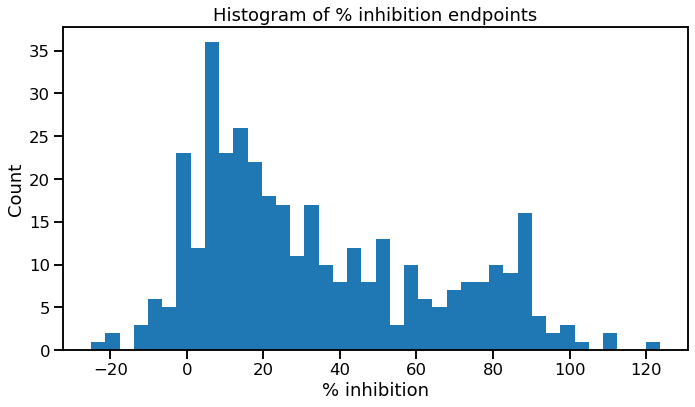

In [5]:
plt.figure(figsize=(10,6))
plt.hist(df_points["pct_inhib"], bins=40)
plt.xlabel("% inhibition")
plt.ylabel("Count")
plt.title("Histogram of % inhibition endpoints")
plt.tight_layout()
plt.show()


## 3.2 Boxplots


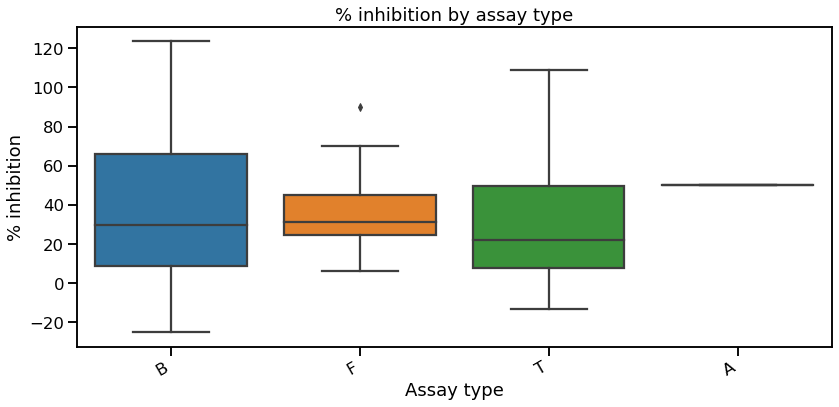

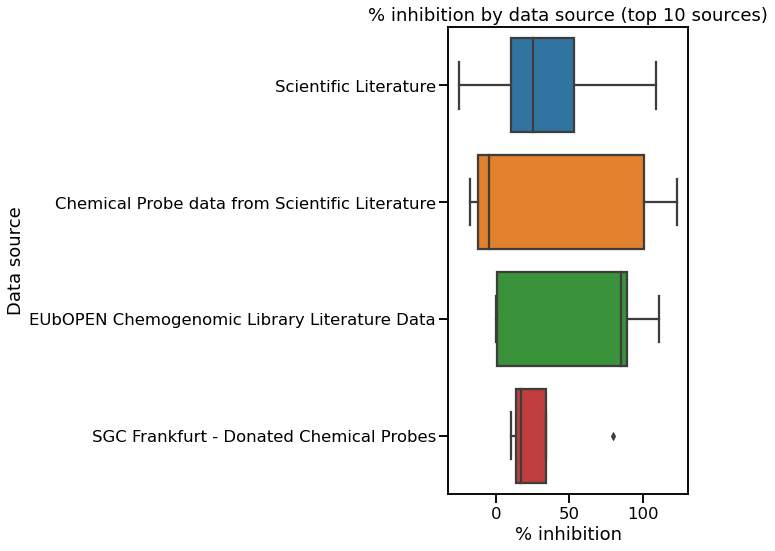

In [6]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df_points, x="assay_type", y="pct_inhib")
plt.xlabel("Assay type")
plt.ylabel("% inhibition")
plt.title("% inhibition by assay type")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

top_sources = df_points["source_description"].value_counts().head(10).index.tolist()
df_top_sources = df_points[df_points["source_description"].isin(top_sources)].copy()

plt.figure(figsize=(10,8))
sns.boxplot(data=df_top_sources, y="source_description", x="pct_inhib", order=top_sources)
plt.ylabel("Data source")
plt.xlabel("% inhibition")
plt.title("% inhibition by data source (top 10 sources)")
plt.tight_layout()
plt.show()


## 3.3 Unique compounds per assay and per source


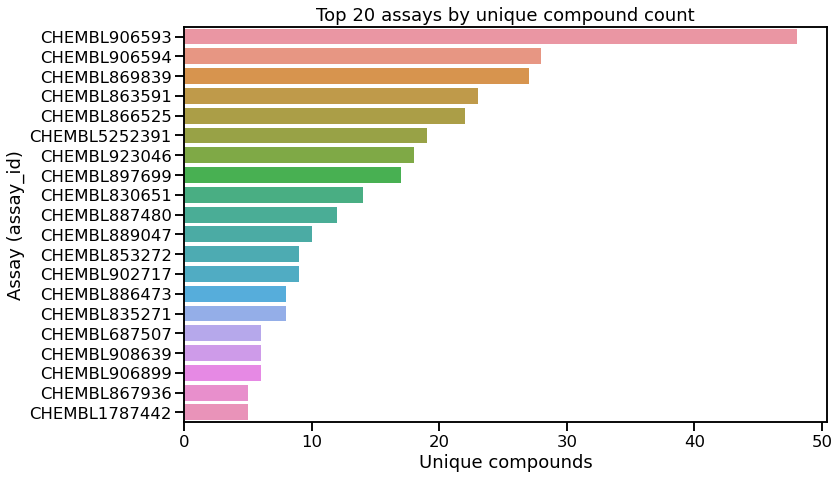

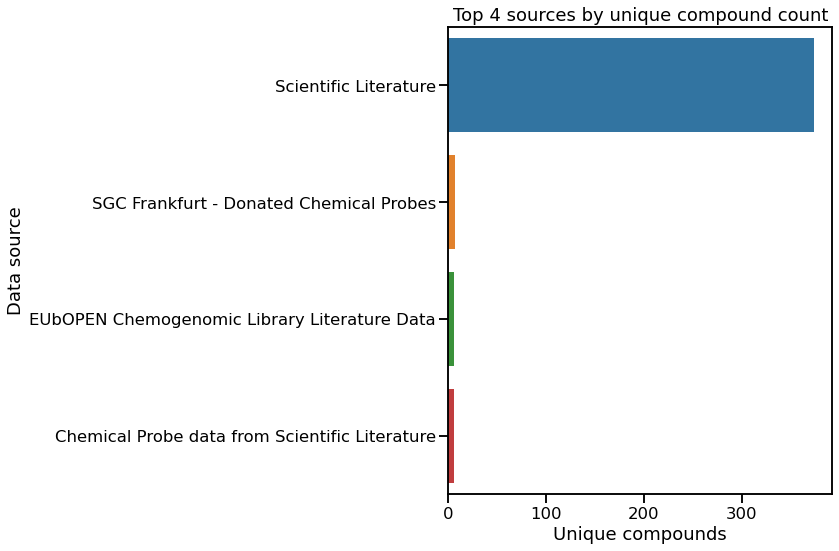

,assay_id,n_unique_compounds
0,CHEMBL906593,48
1,CHEMBL906594,28
2,CHEMBL869839,27
3,CHEMBL863591,23
4,CHEMBL866525,22
5,CHEMBL5252391,19
6,CHEMBL923046,18
7,CHEMBL897699,17
8,CHEMBL830651,14
9,CHEMBL887480,12


In [7]:
assay_counts = (
    canon.groupby("assay_id")["mol_id"]
      .nunique()
      .sort_values(ascending=False)
      .rename("n_unique_compounds")
      .reset_index()
)

plt.figure(figsize=(12,7))
topN = min(20, len(assay_counts))
sns.barplot(data=assay_counts.head(topN), y="assay_id", x="n_unique_compounds")
plt.xlabel("Unique compounds")
plt.ylabel("Assay (assay_id)")
plt.title(f"Top {topN} assays by unique compound count")
plt.tight_layout()
plt.show()

source_counts = (
    canon.groupby("source_description")["mol_id"]
      .nunique()
      .sort_values(ascending=False)
      .rename("n_unique_compounds")
      .reset_index()
)

plt.figure(figsize=(12,8))
topS = min(15, len(source_counts))
sns.barplot(
    data=source_counts.head(topS),
    y="source_description",
    x="n_unique_compounds",
    order=source_counts.head(topS)["source_description"]
)
plt.xlabel("Unique compounds")
plt.ylabel("Data source")
plt.title(f"Top {topS} sources by unique compound count")
plt.tight_layout()
plt.show()

assay_counts.head(10)


## 3.4 Overlap heatmap across top K assays


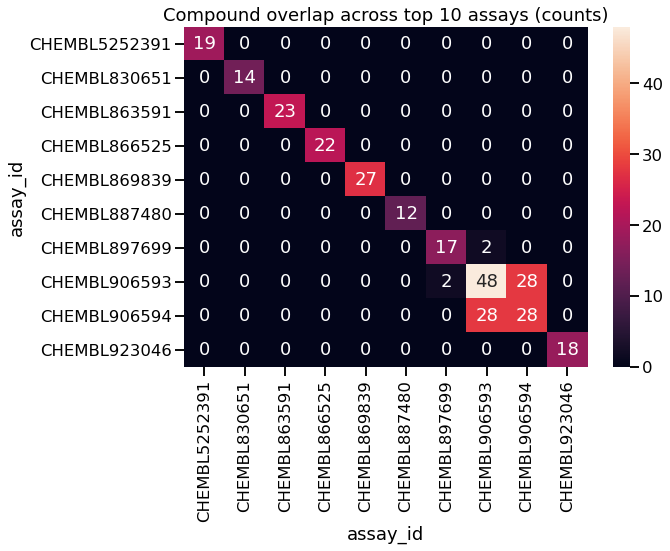

assay_id,CHEMBL5252391,CHEMBL830651,CHEMBL863591,CHEMBL866525,CHEMBL869839,CHEMBL887480,CHEMBL897699,CHEMBL906593,CHEMBL906594,CHEMBL923046
assay_id,,,,,,,,,,
CHEMBL5252391,19,0,0,0,0,0,0,0,0,0
CHEMBL830651,0,14,0,0,0,0,0,0,0,0
CHEMBL863591,0,0,23,0,0,0,0,0,0,0
CHEMBL866525,0,0,0,22,0,0,0,0,0,0
CHEMBL869839,0,0,0,0,27,0,0,0,0,0
CHEMBL887480,0,0,0,0,0,12,0,0,0,0
CHEMBL897699,0,0,0,0,0,0,17,2,0,0
CHEMBL906593,0,0,0,0,0,0,2,48,28,0
CHEMBL906594,0,0,0,0,0,0,0,28,28,0


In [8]:
K = min(10, len(assay_counts))
top_assays = assay_counts.head(K)["assay_id"].astype(str).str.strip().tolist()

presence = (
    canon[canon["assay_id"].isin(top_assays)]
      .drop_duplicates(subset=["mol_id","assay_id"])
      .assign(present=1)
      .pivot_table(index="mol_id", columns="assay_id", values="present", fill_value=0)
)

overlap = presence.T.dot(presence)

plt.figure(figsize=(10,8))
sns.heatmap(overlap, annot=True, fmt="d")
plt.title(f"Compound overlap across top {K} assays (counts)")
plt.tight_layout()
plt.show()

overlap


## 3.5 Scatter plot between two assays (picks best pair based on highest shared number of compounds)


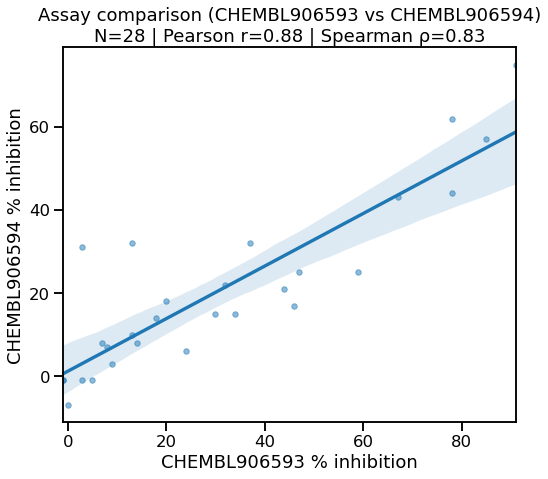

,assay_A,assay_B,N_paired,pearson_r,pearson_p,spearman_r,spearman_p
0,CHEMBL906593,CHEMBL906594,28,0.877923,8.440618e-10,0.826338,6.065746e-08


In [10]:
MIN_PAIRED = 20

# Always reset_index so assay_id is guaranteed to be a column (not index)
agg = (
    df_points.groupby(["mol_id","assay_id"])["pct_inhib"]
    .median()
    .reset_index()
)

# Attach metadata (optional) without risking KeyError
meta_cols = ["assay_type","assay_description","source_description","test_concentration_M"]
meta = (df_points.groupby(["mol_id","assay_id"], as_index=False)[meta_cols].first())
agg = agg.merge(meta, on=["mol_id","assay_id"], how="left")

# Sanity: ensure columns exist
assert "assay_id" in agg.columns and "mol_id" in agg.columns and "pct_inhib" in agg.columns

cand = agg[agg["assay_id"].isin(top_assays)].copy()

best = None
best_n = -1

for a,b in combinations(top_assays, 2):
    sub = cand[cand["assay_id"].isin([a,b])]
    piv = sub.pivot(index="mol_id", columns="assay_id", values="pct_inhib")
    if (a not in piv.columns) or (b not in piv.columns):
        continue
    piv2 = piv[[a,b]].dropna()
    n = piv2.shape[0]
    if n >= MIN_PAIRED and n > best_n:
        best = (a,b,piv2)
        best_n = n

if best is None:
    print(f"No assay pair met MIN_PAIRED={MIN_PAIRED}. Try MIN_PAIRED=10–25 or increase K.")
else:
    a,b,pair_df = best
    x = pair_df[a].values
    y = pair_df[b].values

    pearson_r, pearson_p = stats.pearsonr(x,y)
    spearman_r, spearman_p = stats.spearmanr(x,y)

    plt.figure(figsize=(8,7))
    sns.regplot(x=x, y=y, scatter_kws=dict(alpha=0.5, s=30))
    plt.xlabel(f"{a} % inhibition")
    plt.ylabel(f"{b} % inhibition")
    plt.title(f"Assay comparison ({a} vs {b})\nN={len(pair_df)} | Pearson r={pearson_r:.2f} | Spearman ρ={spearman_r:.2f}")
    plt.tight_layout()
    plt.show()

    display(pd.DataFrame({
        "assay_A":[a],"assay_B":[b],"N_paired":[len(pair_df)],
        "pearson_r":[pearson_r],"pearson_p":[pearson_p],
        "spearman_r":[spearman_r],"spearman_p":[spearman_p]
    }))


## 3.6 Bland–Altman


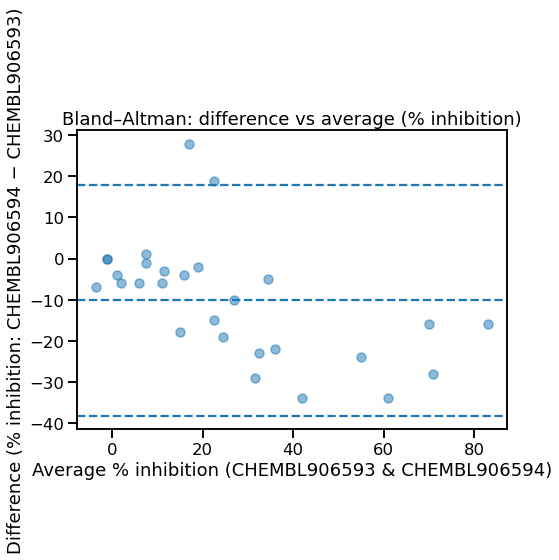

,mean_diff,sd_diff,loa_lower,loa_upper
0,-10.142857,14.326133,-38.222078,17.936364


In [11]:
def bland_altman_plot(x, y, label_x="Assay A", label_y="Assay B"):
    x = np.asarray(x); y = np.asarray(y)
    avg = (x + y) / 2.0
    diff = y - x
    md = np.mean(diff)
    sd = np.std(diff, ddof=1)
    loa_upper = md + 1.96 * sd
    loa_lower = md - 1.96 * sd

    plt.figure(figsize=(8,7))
    plt.scatter(avg, diff, alpha=0.5)
    plt.axhline(md, linestyle="--")
    plt.axhline(loa_upper, linestyle="--")
    plt.axhline(loa_lower, linestyle="--")
    plt.xlabel(f"Average % inhibition ({label_x} & {label_y})")
    plt.ylabel(f"Difference (% inhibition: {label_y} − {label_x})")
    plt.title("Bland–Altman: difference vs average (% inhibition)")
    plt.tight_layout()
    plt.show()

    return {"mean_diff": md, "sd_diff": sd, "loa_lower": loa_lower, "loa_upper": loa_upper}

if 'best' in globals() and best is not None:
    display(pd.DataFrame([bland_altman_plot(pair_df[a], pair_df[b], label_x=a, label_y=b)]))


# Section 4 — Assay comparison & concordance


## 4.1 Identify assay pairs with overlap ≥ N_OVERLAP


In [12]:
N_OVERLAP = 20

M = min(15, len(assay_counts))
top_assays_M = assay_counts.head(M)["assay_id"].astype(str).str.strip().tolist()

candM = agg[agg["assay_id"].isin(top_assays_M)].copy()

overlap_rows = []
for a,b in combinations(top_assays_M, 2):
    sub = candM[candM["assay_id"].isin([a,b])]
    piv = sub.pivot(index="mol_id", columns="assay_id", values="pct_inhib")
    if (a not in piv.columns) or (b not in piv.columns):
        continue
    n = piv[[a,b]].dropna().shape[0]
    if n >= N_OVERLAP:
        overlap_rows.append({"assay_A": a, "assay_B": b, "N_paired": n})

pairs_df = pd.DataFrame(overlap_rows).sort_values("N_paired", ascending=False)
print("Pairs meeting overlap threshold:", len(pairs_df))
pairs_df.head(10)


Pairs meeting overlap threshold: 1


,assay_A,assay_B,N_paired
0,CHEMBL906593,CHEMBL906594,28


## 4.2 Correlations + binary metrics


In [13]:
def binarize(p, thr=PCT_ACTIVE_THRESHOLD):
    return (np.asarray(p) >= thr).astype(int)

def sensitivity_specificity_from_cm(cm):
    tn, fp, fn, tp = cm.ravel()
    sens = tp / (tp + fn) if (tp + fn) else np.nan
    spec = tn / (tn + fp) if (tn + fp) else np.nan
    return sens, spec

results = []
skipped = 0

for row in pairs_df.itertuples(index=False):
    a = str(row.assay_A).strip()
    b = str(row.assay_B).strip()

    sub = candM[candM["assay_id"].isin([a,b])]
    piv = sub.pivot(index="mol_id", columns="assay_id", values="pct_inhib")

    if (a not in piv.columns) or (b not in piv.columns):
        skipped += 1
        continue

    piv2 = piv[[a,b]].dropna()
    if len(piv2) == 0:
        skipped += 1
        continue

    x = piv2[a].values
    y = piv2[b].values

    pearson_r, pearson_p = stats.pearsonr(x,y)
    spearman_r, spearman_p = stats.spearmanr(x,y)

    xb = binarize(x)
    yb = binarize(y)

    kappa = cohen_kappa_score(xb, yb)
    acc = accuracy_score(xb, yb)
    cm = confusion_matrix(xb, yb, labels=[0,1])
    sens, spec = sensitivity_specificity_from_cm(cm)

    results.append({
        "assay_A": a,
        "assay_B": b,
        "N_paired": len(piv2),
        "pearson_r": pearson_r,
        "pearson_p": pearson_p,
        "spearman_r": spearman_r,
        "spearman_p": spearman_p,
        "kappa": kappa,
        "accuracy": acc,
        "sensitivity": sens,
        "specificity": spec,
        "confusion_matrix_[tn_fp;fn_tp]": cm.tolist(),
    })

results_table = pd.DataFrame(results).sort_values(["N_paired","pearson_r"], ascending=[False, False])

print("Pairs requested:", len(pairs_df), "| computed:", len(results_table), "| skipped:", skipped)
results_table.head(10)


Pairs requested: 1 | computed: 1 | skipped: 0


,assay_A,assay_B,N_paired,pearson_r,pearson_p,spearman_r,spearman_p,kappa,accuracy,sensitivity,specificity,confusion_matrix_[tn_fp;fn_tp]
0,CHEMBL906593,CHEMBL906594,28,0.877923,8.440618e-10,0.826338,6.065746e-08,0.611111,0.892857,0.5,1.0,"[[22, 0], [3, 3]]"


## 4.3 Plots for top assay pairs


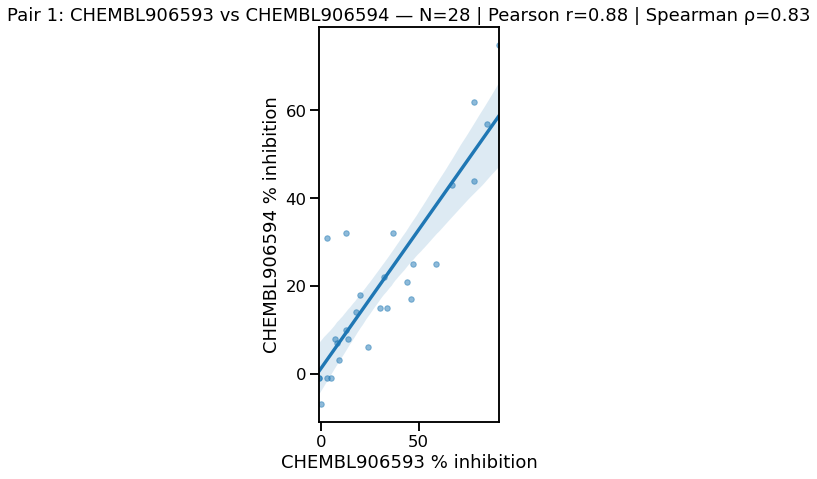

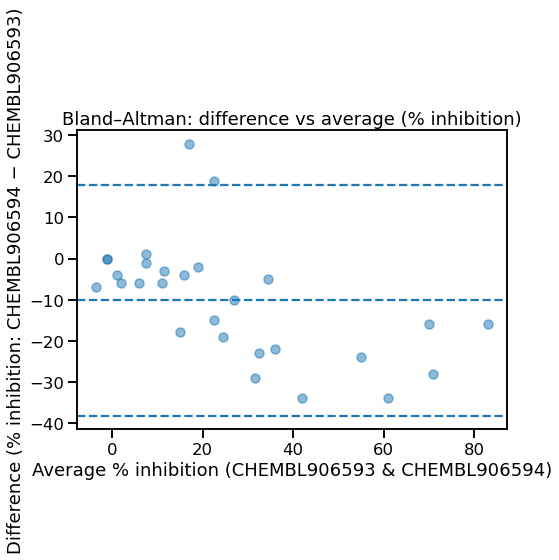

In [14]:
TOP_PLOT_PAIRS = min(3, len(results_table))

def scatter_with_corr(x, y, label_x, label_y, title_prefix=""):
    pearson_r, _ = stats.pearsonr(x,y)
    spearman_r, _ = stats.spearmanr(x,y)

    plt.figure(figsize=(8,7))
    sns.regplot(x=x, y=y, scatter_kws=dict(alpha=0.5, s=30))
    plt.xlabel(f"{label_x} % inhibition")
    plt.ylabel(f"{label_y} % inhibition")
    plt.title(f"{title_prefix}N={len(x)} | Pearson r={pearson_r:.2f} | Spearman ρ={spearman_r:.2f}")
    plt.tight_layout()
    plt.show()

for i in range(TOP_PLOT_PAIRS):
    a = results_table.iloc[i]["assay_A"]
    b = results_table.iloc[i]["assay_B"]

    sub = candM[candM["assay_id"].isin([a,b])]
    piv = sub.pivot(index="mol_id", columns="assay_id", values="pct_inhib")
    piv2 = piv[[a,b]].dropna()

    scatter_with_corr(piv2[a].values, piv2[b].values, a, b, title_prefix=f"Pair {i+1}: {a} vs {b} — ")
    bland_altman_plot(piv2[a].values, piv2[b].values, label_x=a, label_y=b)
